In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
stocks = {
    # Banking
    "HDFCBANK.NS": "Banking",
    "ICICIBANK.NS": "Banking",
    "SBIN.NS": "Banking",
    # IT
    "TCS.NS": "IT",
    "INFY.NS": "IT",
    "WIPRO.NS": "IT",
    # FMCG
    "INDUNHILVR.NS": "FMCG",
    "ITC.NS": "FMCG",
    "NESTLEIND.NS": "FMCG",
    # Auto
    "MARUTI.NS": "Auto",
    "EICHERMOT .NS": "Auto",
    "M&M.NS": "Auto",
    # Pharma
    "SUNPHARMA.NS": "Pharma",
    "CIPLA.NS": "Pharma",
    "DRREDDY.NS": "Pharma",
}
benchmark = "^NSEI"  # Nifty 50 index

In [3]:
tickers = list(stocks.keys()) + [benchmark]

price_data = {}

for ticker in tickers:
    print(f"Downloading {ticker}...")
    
    df = yf.download(
        ticker,
        start="2021-01-01",
        end="2026-01-01",
        auto_adjust=False,
        progress=False
    )
    
    # Check if download failed
    if df.empty:
        print(f"⚠️ No data found for {ticker} - skipping")
        continue
    
    # Get Close price
    close = df["Close"]
    
    # Convert to Series if needed
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    
    price_data[ticker] = close

# Combine everything
prices = pd.concat(price_data, axis=1)

print("\nFinal shape:", prices.shape)
prices.head()


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: INDUNHILVR.NS"}}}
$INDUNHILVR.NS: possibly delisted; no timezone found

1 Failed download:
['INDUNHILVR.NS']: possibly delisted; no timezone found


⚠️ No data found for INDUNHILVR.NS - skipping


$EICHERMOT: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: .NS"}}}
$.NS: possibly delisted; no timezone found

2 Failed downloads:
['EICHERMOT', '.NS']: possibly delisted; no timezone found


⚠️ No data found for EICHERMOT .NS - skipping

Final shape: (1236, 14)


,HDFCBANK.NS,ICICIBANK.NS,SBIN.NS,TCS.NS,INFY.NS,WIPRO.NS,ITC.NS,NESTLEIND.NS,MARUTI.NS,M&M.NS,SUNPHARMA.NS,CIPLA.NS,DRREDDY.NS,^NSEI
Date,,,,,,,,,,,,,,
2021-01-01,712.525024,527.500000,279.399994,2928.250000,1260.449951,194.050003,205.919418,922.534973,7691.299805,732.450012,596.250000,826.599976,1048.270020,14018.500000
2021-01-04,708.000000,531.700012,281.049988,3039.449951,1288.250000,198.199997,205.486115,918.897522,7702.299805,749.099976,604.400024,832.250000,1054.449951,14132.900391
2021-01-05,713.349976,537.250000,281.750000,3093.000000,1293.800049,203.149994,203.608429,927.912476,7655.450195,740.099976,603.450012,827.250000,1057.380005,14199.500000
2021-01-06,710.275024,546.700012,285.049988,3051.500000,1282.099976,203.199997,197.782791,925.762512,7628.600098,736.099976,605.299988,824.799988,1057.660034,14146.250000
2021-01-07,708.125000,541.099976,287.700012,3032.800049,1262.150024,203.375000,195.279205,906.364990,7566.049805,744.400024,601.900024,826.549988,1054.180054,14137.349609


In [4]:
price_data

{'HDFCBANK.NS': Date
 2021-01-01    712.525024
 2021-01-04    708.000000
 2021-01-05    713.349976
 2021-01-06    710.275024
 2021-01-07    708.125000
                  ...    
 2025-12-24    997.200012
 2025-12-26    992.099976
 2025-12-29    991.700012
 2025-12-30    990.900024
 2025-12-31    991.200012
 Name: HDFCBANK.NS, Length: 1236, dtype: float64,
 'ICICIBANK.NS': Date
 2021-01-01     527.500000
 2021-01-04     531.700012
 2021-01-05     537.250000
 2021-01-06     546.700012
 2021-01-07     541.099976
                  ...     
 2025-12-24    1359.800049
 2025-12-26    1350.400024
 2025-12-29    1343.300049
 2025-12-30    1342.500000
 2025-12-31    1342.900024
 Name: ICICIBANK.NS, Length: 1236, dtype: float64,
 'SBIN.NS': Date
 2021-01-01    279.399994
 2021-01-04    281.049988
 2021-01-05    281.750000
 2021-01-06    285.049988
 2021-01-07    287.700012
                  ...    
 2025-12-24    968.950012
 2025-12-26    966.299988
 2025-12-29    965.049988
 2025-12-30    973.450

## Cleaning the data

In [5]:
prices.isna().sum()

HDFCBANK.NS     0
ICICIBANK.NS    0
SBIN.NS         0
TCS.NS          0
INFY.NS         0
WIPRO.NS        0
ITC.NS          0
NESTLEIND.NS    0
MARUTI.NS       0
M&M.NS          0
SUNPHARMA.NS    0
CIPLA.NS        0
DRREDDY.NS      0
^NSEI           0
dtype: int64

In [6]:
threshold = 0.05*len(prices)
prices_clean = prices.dropna(axis=1,thresh=len(prices) - threshold)

prices_clean = prices_clean.ffill()
print(prices_clean.shape)

(1236, 14)


### Saving it to excel

In [7]:
prices_clean.to_csv(r'C:\Users\saisu\Desktop\Project\prices_clean.csv')

### Connecting to a database

In [8]:
conn = sqlite3.connect("C:\\Users\\saisu\\Desktop\\Project\\portfolio.db")

In [9]:
price_data = pd.DataFrame(price_data)

In [10]:
price_data.to_sql('daily_prices',conn,if_exists = 'replace')

1236

### Creating a table to see which sector each stock belongs to

In [11]:
metadata = pd.DataFrame(
    [{"Ticker": t, "Sector": s} for t, s in stocks.items()]
)

In [12]:
metadata.to_sql('stock_meta',conn,if_exists='replace',index=False)

conn.commit()

### Viewing all the closing prices of FMCG stocks

In [13]:
# Check existing column names in the daily_prices table
pd.read_sql("PRAGMA table_info(daily_prices)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Date,TIMESTAMP,0,None,0
1,1,HDFCBANK.NS,REAL,0,None,0
2,2,ICICIBANK.NS,REAL,0,None,0
3,3,SBIN.NS,REAL,0,None,0
4,4,TCS.NS,REAL,0,None,0
5,5,INFY.NS,REAL,0,None,0
6,6,WIPRO.NS,REAL,0,None,0
7,7,ITC.NS,REAL,0,None,0
8,8,NESTLEIND.NS,REAL,0,None,0
9,9,MARUTI.NS,REAL,0,None,0


In [14]:
query = """
SELECT Date, "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS"
FROM daily_prices
ORDER BY Date
"""

fmcg_prices = pd.read_sql(query, conn)
fmcg_prices.head()

,Date,"""HINDUNILVR.NS""",ITC.NS,NESTLEIND.NS
0,2021-01-01 00:00:00,HINDUNILVR.NS,205.919418,922.534973
1,2021-01-04 00:00:00,HINDUNILVR.NS,205.486115,918.897522
2,2021-01-05 00:00:00,HINDUNILVR.NS,203.608429,927.912476
3,2021-01-06 00:00:00,HINDUNILVR.NS,197.782791,925.762512
4,2021-01-07 00:00:00,HINDUNILVR.NS,195.279205,906.364990


### Viewing all the closing prices of IT stocks

In [15]:
query = """
SELECT Date, "TCS.NS", "INFY.NS", "WIPRO.NS"
FROM daily_prices
ORDER BY Date
"""

it_prices = pd.read_sql(query, conn)
it_prices.head()

,Date,TCS.NS,INFY.NS,WIPRO.NS
0,2021-01-01 00:00:00,2928.250000,1260.449951,194.050003
1,2021-01-04 00:00:00,3039.449951,1288.250000,198.199997
2,2021-01-05 00:00:00,3093.000000,1293.800049,203.149994
3,2021-01-06 00:00:00,3051.500000,1282.099976,203.199997
4,2021-01-07 00:00:00,3032.800049,1262.150024,203.375000


### Recent 10 day trading IT stocks


In [16]:
query = """
SELECT Date, "TCS.NS", "INFY.NS", "WIPRO.NS"
FROM daily_prices
ORDER BY Date DESC
LIMIT 10
"""

IT_prices = pd.read_sql(query, conn)
IT_prices

,Date,TCS.NS,INFY.NS,WIPRO.NS
0,2025-12-31 00:00:00,3206.199951,1615.400024,263.279999
1,2025-12-30 00:00:00,3246.800049,1621.599976,263.649994
2,2025-12-29 00:00:00,3251.500000,1644.699951,264.239990
3,2025-12-26 00:00:00,3280.000000,1656.099976,266.299988
4,2025-12-24 00:00:00,3319.000000,1663.400024,268.059998
5,2025-12-23 00:00:00,3310.000000,1668.300049,271.399994
6,2025-12-22 00:00:00,3324.899902,1689.599976,272.670013
7,2025-12-19 00:00:00,3282.000000,1638.699951,264.450012
8,2025-12-18 00:00:00,3280.800049,1626.800049,263.850006
9,2025-12-17 00:00:00,3217.800049,1602.000000,261.140015


In [17]:
it_prices.head()

,Date,TCS.NS,INFY.NS,WIPRO.NS
0,2021-01-01 00:00:00,2928.250000,1260.449951,194.050003
1,2021-01-04 00:00:00,3039.449951,1288.250000,198.199997
2,2021-01-05 00:00:00,3093.000000,1293.800049,203.149994
3,2021-01-06 00:00:00,3051.500000,1282.099976,203.199997
4,2021-01-07 00:00:00,3032.800049,1262.150024,203.375000


### Calculating Daily, Annual Returns and Volatility

In [30]:
daily_returns = prices.pct_change().dropna()
print(f'Daily returns:\n{daily_returns.head()}\n')

Daily returns:
            HDFCBANK.NS  ICICIBANK.NS   SBIN.NS    TCS.NS   INFY.NS  WIPRO.NS  \
Date                                                                            
2021-01-04    -0.006351      0.007962  0.005905  0.037975  0.022056  0.021386   
2021-01-05     0.007556      0.010438  0.002491  0.017618  0.004308  0.024975   
2021-01-06    -0.004311      0.017590  0.011712 -0.013417 -0.009043  0.000246   
2021-01-07    -0.003027     -0.010243  0.009297 -0.006128 -0.015560  0.000861   
2021-01-08     0.010874      0.001756 -0.005909  0.029049  0.039575  0.057652   

              ITC.NS  NESTLEIND.NS  MARUTI.NS    M&M.NS  SUNPHARMA.NS  \
Date                                                                    
2021-01-04 -0.002104     -0.003943   0.001430  0.022732      0.013669   
2021-01-05 -0.009138      0.009811  -0.006083 -0.012014     -0.001572   
2021-01-06 -0.028612     -0.002317  -0.003507 -0.005405      0.003066   
2021-01-07 -0.012658     -0.020953  -0.008199  0.011

In [32]:
annualized_returns = daily_returns.mean() * 252
print(f'Annual Returns:\n{annualized_returns}')

Annual Returns:
HDFCBANK.NS     0.089984
ICICIBANK.NS    0.214920
SBIN.NS         0.291238
TCS.NS          0.040071
INFY.NS         0.079799
WIPRO.NS        0.095818
ITC.NS          0.157567
NESTLEIND.NS    0.085474
MARUTI.NS       0.185283
M&M.NS          0.371573
SUNPHARMA.NS    0.238001
CIPLA.NS        0.149732
DRREDDY.NS      0.063225
^NSEI           0.136884
dtype: float64


In [41]:
annual_volatility = daily_returns.std() * np.sqrt(252)
print(f'Annual Volatility:\n{annual_volatility}')

Annual Volatility:
HDFCBANK.NS     0.212796
ICICIBANK.NS    0.220774
SBIN.NS         0.263102
TCS.NS          0.207875
INFY.NS         0.241407
WIPRO.NS        0.259272
ITC.NS          0.202851
NESTLEIND.NS    0.186594
MARUTI.NS       0.233289
M&M.NS          0.284725
SUNPHARMA.NS    0.209319
CIPLA.NS        0.231248
DRREDDY.NS      0.217968
^NSEI           0.139877
dtype: float64


In [33]:
#Calculation of Sharpe Ratio
risk_free_rate = 0.06 # Assuming 6% risk-free rate

sharpe_ratios = (annualized_returns - risk_free_rate) / annual_volatility
print(f'Sharpe Ratios:\n{sharpe_ratios.sort_values(ascending=False).head(10)}')  

Sharpe Ratios:
M&M.NS          1.094294
SBIN.NS         0.878893
SUNPHARMA.NS    0.850381
ICICIBANK.NS    0.701713
^NSEI           0.549652
MARUTI.NS       0.537027
ITC.NS          0.480978
CIPLA.NS        0.388032
HDFCBANK.NS     0.140905
WIPRO.NS        0.138148
dtype: float64


From the above Sharpe Ratios, M$M leads the chart with the highest sharpe ratio (1.09).They provide the best risk adjusted return at 6% risk-free rate. SBI (0.87), SunPharma (0.85) and ICICI bank (0.70) have outperformed the market benchmark on risk adjusted basis. Nifty 50 is set as a baseline for the stocks at 0.55. Stocks below a sharpe ratio of 0.55 are likely to provide less return per unit of risk.

In [ ]:
# Calculation of Beta (sensitivity to market movements)

benchmark = '^NSEI'  # Nifty 50 index
cov = daily_returns.cov()[benchmark]
benchmark_var = daily_returns[benchmark].var()

beta = cov / benchmark_var
print(f'Beta Values:\n{beta.sort_values(ascending=False).head(10)}')

Beta Values:
SBIN.NS         1.231073
M&M.NS          1.144979
ICICIBANK.NS    1.082284
HDFCBANK.NS     1.056509
WIPRO.NS        1.022690
^NSEI           1.000000
INFY.NS         0.957691
MARUTI.NS       0.814369
TCS.NS          0.785842
ITC.NS          0.674041
Name: ^NSEI, dtype: float64


From the above Beta values, SBI, M&M, ICICI, HDFC and Wipro and more volatile than the market. If Nifty 50 moves up or down by 1%, State Bank of India tends to move roughly 1.23% in the same direction. NSEI serves as the benchmark to understand the volatility of other stocks. Maruti, TCS and ITC are very defensive. If the market drops by 1%, ITC is expected to drop by only about 0.67%.

In [38]:
# Correlation Matrix
correlation_matrix = daily_returns.corr()
print(f'Correlation Matrix:\n{correlation_matrix}')

Correlation Matrix:
              HDFCBANK.NS  ICICIBANK.NS   SBIN.NS    TCS.NS   INFY.NS  \
HDFCBANK.NS      1.000000      0.531632  0.423681  0.229695  0.258390   
ICICIBANK.NS     0.531632      1.000000  0.558693  0.218879  0.264989   
SBIN.NS          0.423681      0.558693  1.000000  0.203273  0.194256   
TCS.NS           0.229695      0.218879  0.203273  1.000000  0.702128   
INFY.NS          0.258390      0.264989  0.194256  0.702128  1.000000   
WIPRO.NS         0.281847      0.257070  0.264632  0.605258  0.635917   
ITC.NS           0.226371      0.286886  0.333197  0.168533  0.178757   
NESTLEIND.NS     0.165226      0.167611  0.113934  0.228907  0.189857   
MARUTI.NS        0.279842      0.291780  0.317452  0.199173  0.183717   
M&M.NS           0.330770      0.362330  0.364136  0.222109  0.262643   
SUNPHARMA.NS     0.186725      0.222470  0.194747  0.212765  0.205617   
CIPLA.NS         0.082242      0.064414  0.071607  0.162075  0.157045   
DRREDDY.NS       0.147789      

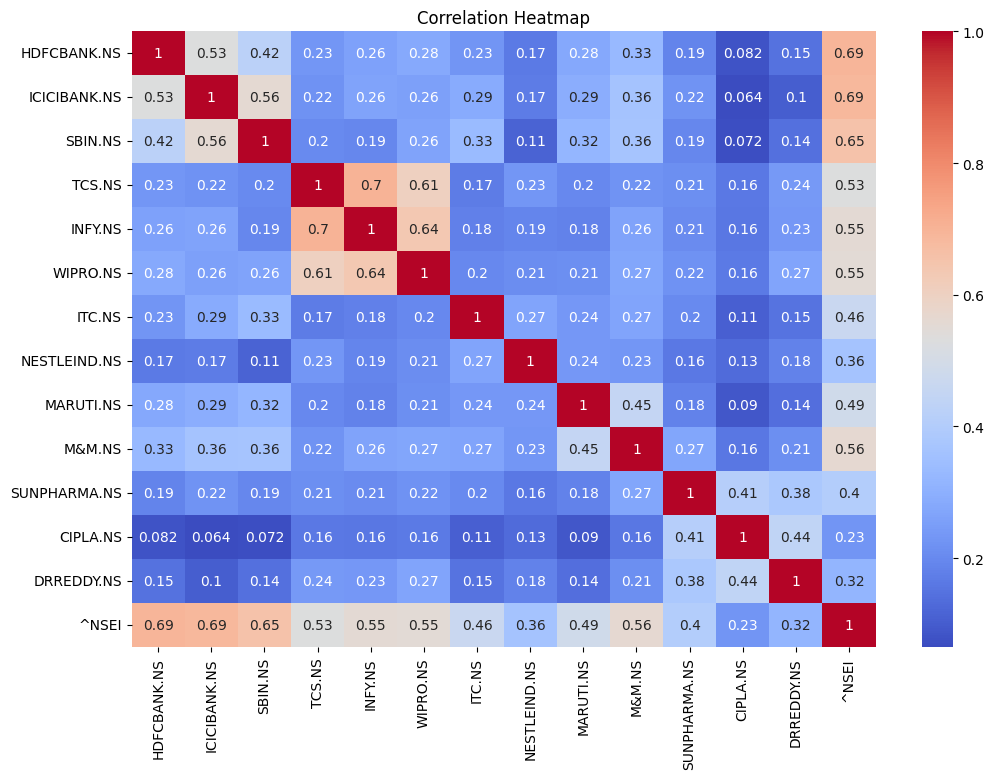

In [39]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The above correlation heatmap, talks about the daily returns of all the stocks and Nifty 50 index. The IT stocks (TCS, Infosys, Wipro) exhibit the highest correlation on the map at 0.70. Holding multiple IT stocks provides minimal sector diversification. ICICI Bank shares a correlation of 0.56 with SBI,and 0.53 with HDFC bank.

In [43]:
# 1. Combine your calculated metrics into a DataFrame
summary = pd.DataFrame({
    'Annual_Volatility': annual_volatility,
    'Sharpe_Ratio': sharpe_ratios,
    'Beta': beta
})

# 2. Save to SQLite database
summary.to_sql("stock_summary", conn, if_exists="replace")
conn.commit()
print("Summary saved to database")

Summary saved to database


In [44]:
summary.head()

,Annual_Volatility,Sharpe_Ratio,Beta
HDFCBANK.NS,0.212796,0.140905,1.056509
ICICIBANK.NS,0.220774,0.701713,1.082284
SBIN.NS,0.263102,0.878893,1.231073
TCS.NS,0.207875,-0.095872,0.785842
INFY.NS,0.241407,0.082016,0.957691


In [45]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

            name
0   daily_prices
1     stock_meta
2  stock_summary


In [47]:
result = pd.read_sql("SELECT * FROM daily_prices", conn)
print(result)

                     Date  HDFCBANK.NS  ICICIBANK.NS     SBIN.NS       TCS.NS  \
0     2021-01-01 00:00:00   712.525024    527.500000  279.399994  2928.250000   
1     2021-01-04 00:00:00   708.000000    531.700012  281.049988  3039.449951   
2     2021-01-05 00:00:00   713.349976    537.250000  281.750000  3093.000000   
3     2021-01-06 00:00:00   710.275024    546.700012  285.049988  3051.500000   
4     2021-01-07 00:00:00   708.125000    541.099976  287.700012  3032.800049   
...                   ...          ...           ...         ...          ...   
1231  2025-12-24 00:00:00   997.200012   1359.800049  968.950012  3319.000000   
1232  2025-12-26 00:00:00   992.099976   1350.400024  966.299988  3280.000000   
1233  2025-12-29 00:00:00   991.700012   1343.300049  965.049988  3251.500000   
1234  2025-12-30 00:00:00   990.900024   1342.500000  973.450012  3246.800049   
1235  2025-12-31 00:00:00   991.200012   1342.900024  982.200012  3206.199951   

          INFY.NS    WIPRO.

## Modern Portfolio Theory